### 🤖 Guía de Asistencia con IA: Entrenamiento e Interpretación de Modelos Supervisados

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Interpretar coeficientes**: Pídele a la IA: *'En mi modelo de regresión lineal, la variable 'Años de Experiencia' tiene un coeficiente de 2500. ¿Cómo le explico este resultado a un cliente que no sabe estadística?'*.
- **Feature Importance**: Si usas Random Forest, pídele: *'Genera código en scikit-learn para extraer e imprimir el feature importance de mi modelo ordenado de mayor a menor'*.



# Programa Ingenias+ Data Science

# En esta notebook, vamos a demostrar como funcionan los algoritmos vistos en clase y su implementación en Scikit-learn.

# Regresión Lineal

Vamos a empezar generando unos datos para mostrar unos ejemplos

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

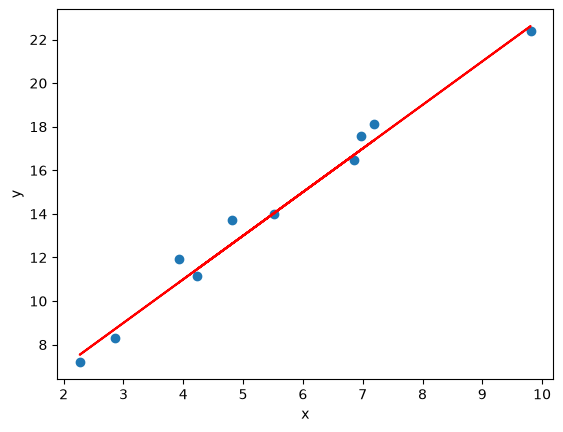

In [2]:
# Creamos datos que sigan una recta
np.random.seed(123)
a = 2
b = 3
x = np.random.rand(10)*10
y = a*x+b + np.random.randn(10)*0.5
plt.scatter(x,y)
plt.plot(x, a*x+b, 'r')
plt.xlabel('x');
plt.ylabel('y');

In [3]:
x

array([6.96469186, 2.86139335, 2.26851454, 5.51314769, 7.1946897 ,
       4.2310646 , 9.80764198, 6.84829739, 4.80931901, 3.92117518])

In [4]:
x.reshape(-1,1)

array([[6.96469186],
       [2.86139335],
       [2.26851454],
       [5.51314769],
       [7.1946897 ],
       [4.2310646 ],
       [9.80764198],
       [6.84829739],
       [4.80931901],
       [3.92117518]])

La búsqueda de un modelo que describa el comportamiento de nuestros datos parte del supuesto de que existe una relación o función matemática subyacente que los relaciona. Nuestro trabajo es encontrar esa función.
Para eso vamos a usar la librería Scikit-Learn

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
# Instanciamos el modelo
lr = LinearRegression()

In [7]:
# Le pedimos que encuentre los parámetros que mejor se ajustan a nuestros datos
lr.fit(x.reshape(-1,1), y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[6.88]


Veamos qué encontró

In [8]:
# Imprimimos la pendiente
lr.coef_

array([2.02565598])

In [9]:
# Imprimimos la ordenada al origen
lr.intercept_

np.float64(3.0600038699795835)

Esto significa que la recta encontrada es $$y = 2.02565598 · x + 3.0600038699795835$$

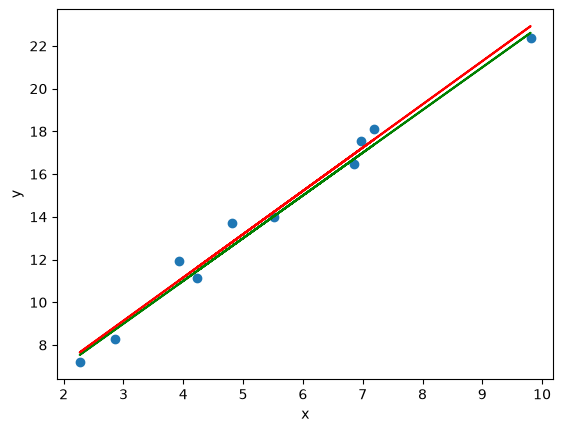

In [10]:
np.random.seed(123)
# y real
a = 2
b = 3
x = np.random.rand(10)*10
y = a*x + b + np.random.randn(10)*0.5
y_real = a*x + b
# y predicha
a_p = lr.coef_
b_p = lr.intercept_
y_predicted = a_p * x + b_p
plt.scatter(x, y)
plt.plot(x, y_real, 'green')
plt.plot(x, y_predicted, 'r')
plt.xlabel('x');
plt.ylabel('y');

# Regresión Logística

Vamos a entrenar un modelo para poder clasificar una observación en una categoría según sus características.



Armemos un dataset de juguete

In [11]:
from sklearn.datasets import make_classification

In [12]:
X, y = make_classification(n_samples = 200,
                           n_features=2,
                           n_informative= 2,
                           n_redundant=0,
                           n_clusters_per_class=2,
                           flip_y = 0.15,
                           random_state=8)

Veamos qué datos obtuvimos

In [13]:
X = pd.DataFrame(X, columns=['x1', 'x2'])
X.head()

,x1,x2
0,-1.189053,-0.648235
1,-1.368230,-0.072432
2,-1.876199,0.345642
3,0.018895,2.690086
4,-1.383127,1.197926


In [14]:
y = pd.Series(y, name='Clase')
y.sample(10)

163    1
157    1
61     1
197    1
91     0
73     1
85     0
81     1
111    1
114    0
Name: Clase, dtype: int64

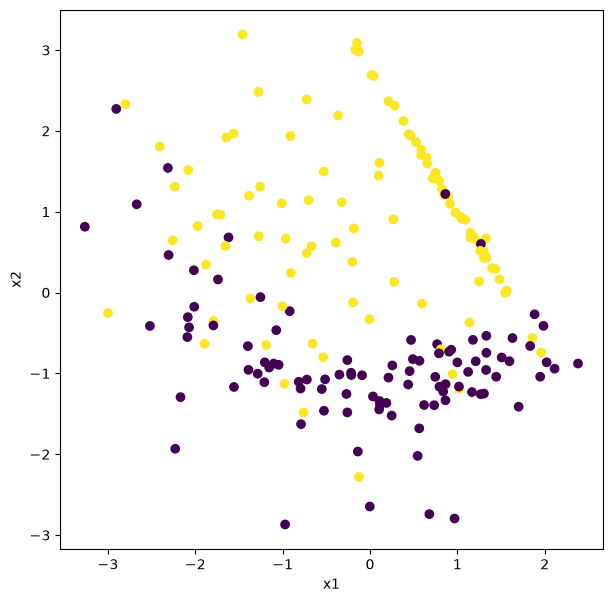

In [15]:
plt.figure(figsize=(7,7))
plt.scatter(X['x1'], X['x2'], c = y)
plt.xlabel('x1')
plt.ylabel('x2')
xlim = plt.xlim()
ylim = plt.ylim()

El objetivo ahora es poder clasificar las observaciones, es decir determinar el color del punto, en función de sus parámetros.

In [16]:
# Importamos la clase
from sklearn.linear_model import LogisticRegression

In [17]:
# Instanciamos el clasificador
lr = LogisticRegression(penalty=None, solver='saga')

In [18]:
# Entrenamos el modelo
lr.fit(X,y)

/home/leaolarte/Curso_YPF_Data_Science/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

Veamos qué encontró.

In [19]:
lr.coef_

array([[0.33258278, 1.95345755]])

In [20]:
lr.intercept_

array([0.26322812])

In [21]:
ejex = np.linspace(X['x1'].min(), X['x1'].max(), num=2)
ejey = -(lr.coef_[0][0]*ejex + lr.intercept_)/lr.coef_[0][1]

Grafiquemos el umbral de decisión.

(-3.171503680070779, 3.4958314570705675)

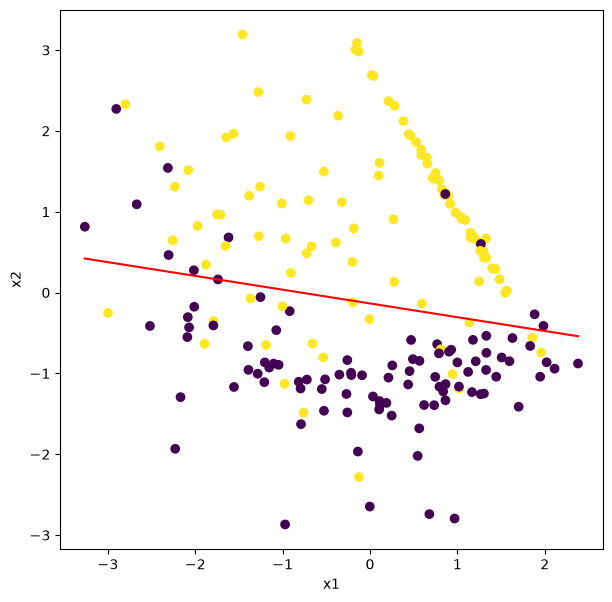

In [22]:
plt.figure(figsize=(7,7))
plt.scatter(X['x1'], X['x2'], c = y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(ejex, ejey, 'r')
plt.xlim(xlim)
plt.ylim(ylim)

In [23]:
y_pred = lr.predict(X)

In [24]:
y.values

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0])

In [25]:
y_pred

array([0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1])

Complejizemos el modelo agregando nuevas features. En este caso agregaremos $x_2^2$

In [26]:
X['x2_cuadrado'] = X['x2']**2
X.head()

,x1,x2,x2_cuadrado
0,-1.189053,-0.648235,0.420209
1,-1.368230,-0.072432,0.005246
2,-1.876199,0.345642,0.119468
3,0.018895,2.690086,7.236562
4,-1.383127,1.197926,1.435027


Volvemos a entrenar el modelo

In [27]:
lr.fit(X,y)

/home/leaolarte/Curso_YPF_Data_Science/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [28]:
lr.coef_

array([[ 0.33547813,  1.99201125, -0.25183127]])

Veamos cómo cambió el umbral de decisión.

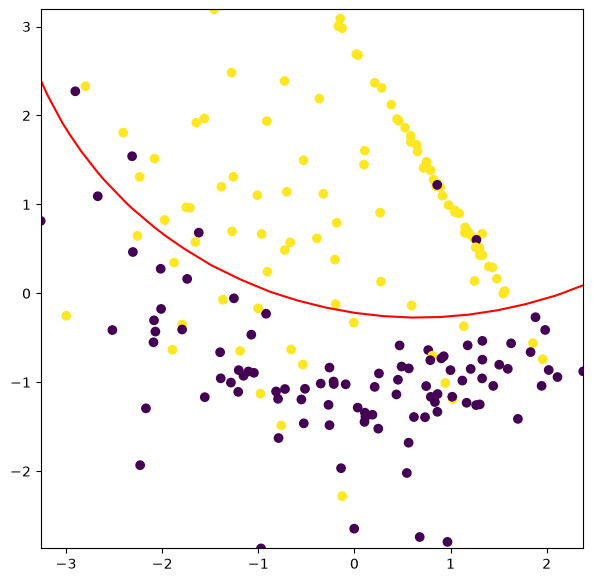

In [29]:
plt.figure(figsize=(7,7))
x1 = np.linspace(X['x1'].min(), X['x1'].max(), 20)
x2 = np.linspace(X['x2'].min(), X['x2'].max(), 20)
x1, x2 = np.meshgrid(x1,x2)
F = lr.coef_[0][0]*x1 + lr.coef_[0][1]*x2 + lr.coef_[0][2]*x1**2 + lr.coef_[0][2]*x2**2+ lr.intercept_
plt.contour(x1,x2,F,[0],colors= 'r')
plt.scatter(X['x1'], X['x2'], c = y)